In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.optim import lr_scheduler
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
# 1. 检测 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前使用的设备: {device}")

# 显示 GPU 的名称（如果可用）
if torch.cuda.is_available():
    print(f"GPU 名称: {torch.cuda.get_device_name(0)}")

当前使用的设备: cuda
GPU 名称: Tesla T4


### 数据集加载

In [3]:
# 训练集：增加数据增强
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 测试集/推理：保持简洁
test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 加载 CIFAR-10
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

100%|██████████| 170M/170M [00:08<00:00, 20.1MB/s] 


### 定义模型

In [4]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = AlexNet(num_classes=10).to(device)

In [5]:
criterion = nn.CrossEntropyLoss()
# 学习率设为 0.01，配合动量
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
# 每 10 个 Epoch 降低一次学习率
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [6]:
print("开始训练模型...")
num_epochs = 5 # 如果时间充裕，可以改为 50

# 初始化记录器
history = {
    'train_loss': [],
    'train_acc': []
}

# 训练循环
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # 记录统计数据
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    # 计算当前 Epoch 的平均值并存入 history
    epoch_loss = running_loss / len(trainloader)
    epoch_acc = 100. * correct / total
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc)
    
    print(f"Epoch {epoch+1}: Loss {epoch_loss:.4f}, Acc {epoch_acc:.2f}%")

开始特训模型...
Epoch 1: Loss 2.1599, Acc 17.69%
Epoch 2: Loss 1.5943, Acc 41.04%
Epoch 3: Loss 1.3233, Acc 51.67%
Epoch 4: Loss 1.1206, Acc 59.89%
Epoch 5: Loss 0.9409, Acc 66.75%


In [7]:
# 暂时保存在colab中
torch.save(model.state_dict(), 'alexnet_pro_cifar10.pth')
print("训练完成且权重已保存！")

训练完成且权重已保存！


In [11]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [13]:
# 查看 MyDrive 下的内容
!ls /content/drive/MyDrive/Colab/images/

2-dogs.jpeg  dog.jpeg  dog.png


In [14]:
def predict_your_dog(img_path):
    # 标签映射
    classes = ('airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck')
    
    # 加载图片
    img = Image.open(img_path).convert('RGB')
    img_tensor = test_transform(img).unsqueeze(0).to(device)
    
    # 推理
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        confidence, predicted = torch.max(probabilities, 0)
    
    # 显示结果
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {classes[predicted.item()]} ({confidence.item()*100:.2f}%)")
    plt.show()

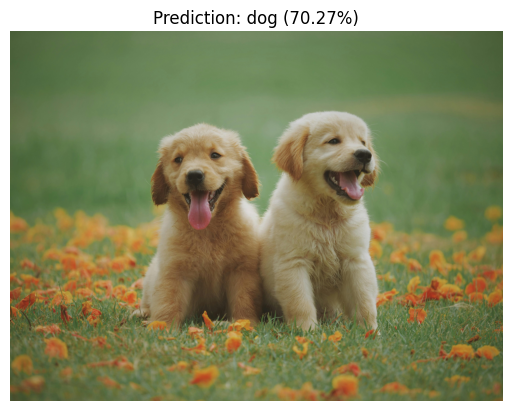

In [15]:
# 调用测试（请确保路径正确）
image_path = '/content/drive/MyDrive/Colab/images/2-dogs.jpeg' # 替换为你实际的图片路径
predict_your_dog(image_path)

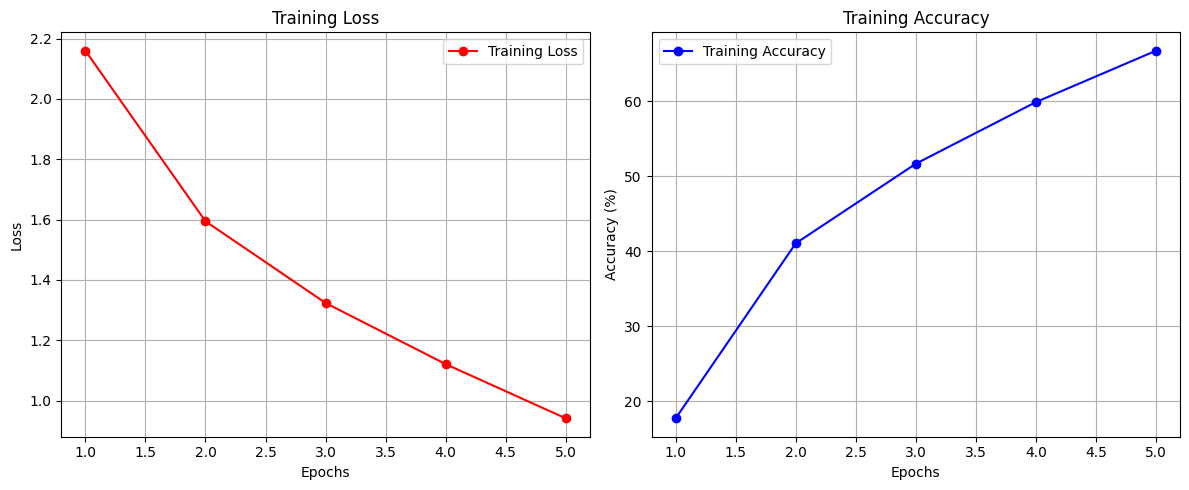

In [16]:
import matplotlib.pyplot as plt

def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))

    # 1. 绘制 Loss 曲线
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'r-o', label='Training Loss')
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # 2. 绘制 Accuracy 曲线
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-o', label='Training Accuracy')
    plt.title('Training Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# 调用绘图
plot_history(history)

### 保存模型权重到云盘

In [11]:
# 建议在云盘里建一个专门的文件夹，比如 'models'
import os
save_path = '/content/drive/MyDrive/Colab/models'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# 保存权重
torch.save(model.state_dict(), os.path.join(save_path, 'alexnet_pro_best.pth'))
print(f"模型已保存至 Google Drive: {save_path}")

模型已保存至 Google Drive: /content/drive/MyDrive/Colab/models
